# 01 · Exploratory Data Analysis (EDA)
### Dirección de Productos de Crédito — Minería de Datos UNAM

Este notebook realiza una **autopsia completa del dataset bancario**.  
El objetivo es entender la estructura, calidad y distribución de los datos  
antes de tomar cualquier decisión de limpieza o modelado.

**Secciones:**
1. Carga y vista general  
2. Tipos de datos y valores únicos  
3. Análisis de valores nulos  
4. Variables categóricas — distribuciones  
5. Variables numéricas — distribuciones y outliers  
6. Validación contra el catálogo  
7. Correlaciones  
8. Resumen de hallazgos y decisiones pendientes


## 0 · Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
PALETTE = "Set2"
RED     = "#c0392b"
BLUE    = "#2980b9"
GREEN   = "#27ae60"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)
print("Librerías cargadas correctamente")


Librerías cargadas correctamente


---
## 1 · Carga y vista general

In [2]:
# Ajusta la ruta si es necesario
DATA_PATH = "E:/github/credit-product-analytics/data/raw/ProyectoMineria-Banco.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8")

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print()
df.head(5)


Shape: 4,352 filas × 27 columnas



,NUM_SOLICITUD,SUCURSAL,STATUS_SOLICITUD,PRODUCTO,APROBACION_TC,TIPO_CTE,LINEA_CREDITO_FINAL,CUENTA_ASIGNADA,MESES_VENCIDOS,SALDO_CUENTA,CAPACIDAD_TC,INGRESO_INFERIDO,COMPROBANTE_INGRESOS,SEGMENTO_CLIENTE,CLIENTE_CDE,SUMA_LINEAS_REVOLVENTES,NIVEL_RIESGO,CAPACIDAD_PAGO_TOTAL,SOLICITUDES_RECHAZADAS,SCORE_CLIENTE,SCORE_COMPORTAMIENTO,SUMA_SALDOS_TARJETAS,SUMA_PAGO_MIN_TARJETAS,NUM_CREDITOS,EDAD,TIPO_VIVIENDA,ESCOLARIDAD
0,"20,140,800,000,000,000.00",113,APROBADA,CREDITO_AUTO,APROBADO,REGULAR,687000,"998,000,000,000,000.00",1.00,"274,800",60.00%,12281,DECLARACION ANUAL,ALTO_A,NO_CLIENTE,0,BAJO,40%,0,242,780,0,0,0,30,FAMILIARES,PREPARATORIA
1,"20,140,800,000,000,000.00",185,APROBADA,CREDITO_AUTO,APROBADO,BUENO,318000,"998,000,000,000,000.00",1.00,"365,700",-15.00%,32366,RECIBOS DE NOMINA,MEDIO_A,CLIENTE_BANCO,240000,BAJO,115%,0,251,740,31269,790,0,27,FAMILIARES,LICENCIATURA
2,"20,140,800,000,000,000.00",143,APROBADA,CREDITO_AUTO,APROBADO,BUENO,317001,"998,000,000,000,000.00",0.00,"288,471",9.00%,44098,RECIBOS DE NOMINA,ALTO_A,CLIENTE_BANCO,127000,BAJO,91%,0,215,704,101992,0,0,28,PROPIA,LICENCIATURA
3,"20,140,800,000,000,000.00",173,APROBADA,CREDITO_AUTO,APROBADO,BUENO,315501,"998,000,000,000,000.00",1.00,63100,9.00%,44098,RECIBOS DE NOMINA,MEDIO_A,CLIENTE_BANCO,127000,BAJO,0.91,0,215,704,101992,0,0,28,PROPIA,LICENCIATURA
4,"20,140,800,000,000,000.00",180,APROBADA,CREDITO_AUTO,APROBADO,BUENO,311101,"998,000,000,000,000.00",1.00,62220,9.00%,44098,RECIBOS DE NOMINA,MEDIO_A,CLIENTE_BANCO,127000,BAJO,91%,0,215,704,101992,0,0,28,PROPIA,LICENCIATURA


In [3]:
# Información general de tipos y memoria
print("══════════════════════════════════════════")
print("  INFORMACIÓN GENERAL DEL DATASET")
print("══════════════════════════════════════════")
df.info(memory_usage="deep")


══════════════════════════════════════════
  INFORMACIÓN GENERAL DEL DATASET
══════════════════════════════════════════
<class 'pandas.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NUM_SOLICITUD            4352 non-null   float64
 1   SUCURSAL                 4352 non-null   int64  
 2   STATUS_SOLICITUD         4352 non-null   str    
 3   PRODUCTO                 4352 non-null   str    
 4   APROBACION_TC            4352 non-null   str    
 5   TIPO_CTE                 4352 non-null   str    
 6   LINEA_CREDITO_FINAL      4352 non-null   int64  
 7   CUENTA_ASIGNADA          1433 non-null   float64
 8   MESES_VENCIDOS           1984 non-null   float64
 9   SALDO_CUENTA             1433 non-null   str    
 10  CAPACIDAD_TC             1654 non-null   str    
 11  INGRESO_INFERIDO         4352 non-null   int64  
 12  COMPROBANTE_INGRESOS   

---
## 2 · Tipos de datos y cardinalidad

Revisamos cuántos valores únicos tiene cada columna para distinguir
variables continuas, ordinales y categóricas nominales.


In [4]:
summary = pd.DataFrame({
    "dtype"   : df.dtypes,
    "n_unique": df.nunique(),
    "n_null"  : df.isnull().sum(),
    "pct_null": (df.isnull().sum() / len(df) * 100).round(2),
    "ejemplo" : [df[c].dropna().unique()[:4] for c in df.columns],
})
display(summary.sort_values("pct_null", ascending=False))


,dtype,n_unique,n_null,pct_null,ejemplo
SALDO_CUENTA,str,1049,2919,67.07,"[274,800, 365,700, 288,471, 63100]"
CUENTA_ASIGNADA,float64,1,2919,67.07,[998000000000000.0]
CAPACIDAD_TC,str,108,2698,61.99,"[60.00%, -15.00%, 9.00%, 20.00%]"
MESES_VENCIDOS,float64,4,2368,54.41,"[1.0, 0.0, 2.0, 3.0]"
STATUS_SOLICITUD,str,5,0,0.00,"[APROBADA, PENDIENTE, EN_PROCESO, CANCELADA]"
NUM_SOLICITUD,float64,11,0,0.00,"[2.01408e+16, 2.01407e+16, 2.01406e+16, 2.0140..."
SUCURSAL,int64,200,0,0.00,"[113, 185, 143, 173]"
LINEA_CREDITO_FINAL,int64,416,0,0.00,"[687000, 318000, 317001, 315501]"
TIPO_CTE,str,3,0,0.00,"[REGULAR, BUENO, MALO]"
APROBACION_TC,str,3,0,0.00,"[APROBADO, PRE-APROBADO, RECHAZADO]"


---
## 3 · Análisis de valores nulos

Un valor nulo puede significar cosas distintas según la columna:
- En `MESES_VENCIDOS` → el catálogo dice que NULL = sin dato (no es cero).
- En columnas como `CUENTA_ASIGNADA` → solo aplica si la solicitud fue aprobada.


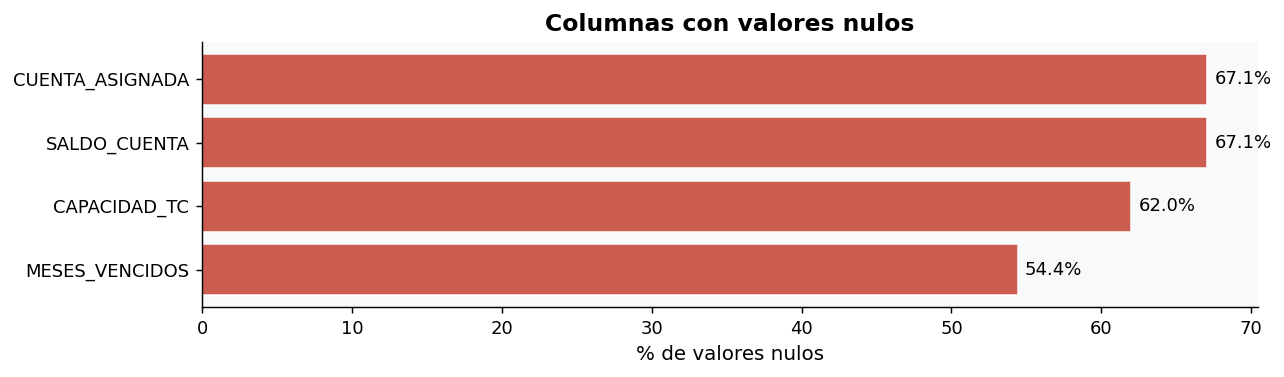


Detalle:
                    0  pct_%
CUENTA_ASIGNADA  2919  67.07
SALDO_CUENTA     2919  67.07
CAPACIDAD_TC     2698  61.99
MESES_VENCIDOS   2368  54.41


In [6]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
pct   = (nulls / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, max(3, len(nulls) * 0.5)))
bars = ax.barh(nulls.index, pct.values, color=RED, alpha=0.82, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in pct.values], padding=4, fontsize=10)
ax.set_xlabel("% de valores nulos")
ax.set_title("Columnas con valores nulos", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/01_nulls.png", bbox_inches="tight")
plt.show()

print("\nDetalle:")
print(pd.concat([nulls, pct.rename("pct_%")], axis=1).to_string())


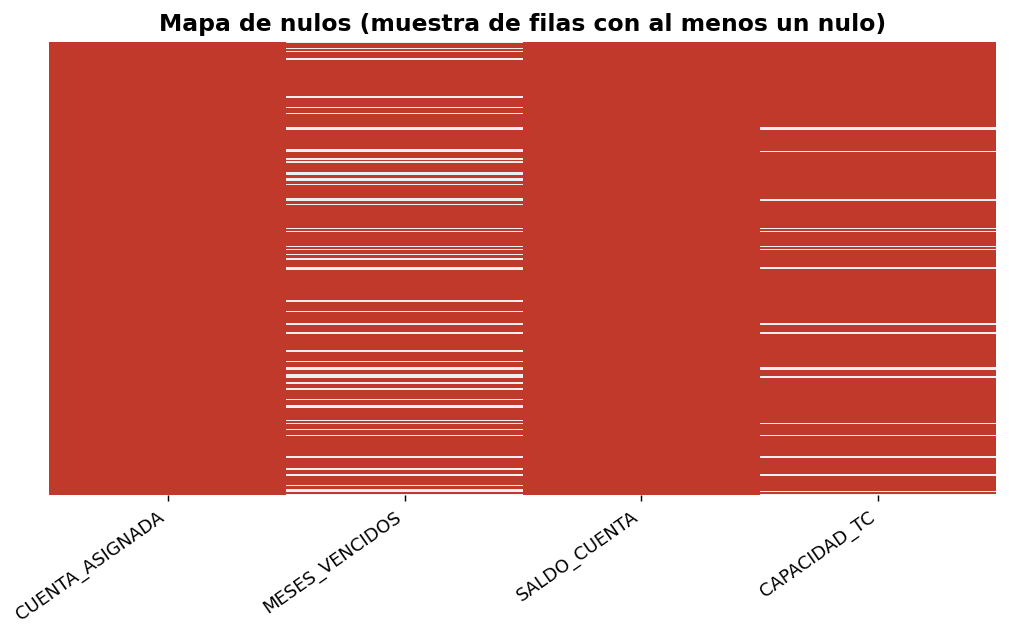

In [7]:
# ── Mapa de calor de nulos (heatmap por segmento de filas) ──────────────────
sample = df[df.isnull().any(axis=1)].sample(min(300, df.isnull().any(axis=1).sum()), random_state=42)
null_cols = df.columns[df.isnull().any()].tolist()

fig, ax = plt.subplots(figsize=(max(8, len(null_cols)*1.1), 5))
sns.heatmap(
    sample[null_cols].isnull(),
    cbar=False, yticklabels=False,
    cmap=["#ecf0f1", RED], ax=ax
)
ax.set_title("Mapa de nulos (muestra de filas con al menos un nulo)", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/01_null_heatmap.png", bbox_inches="tight")
plt.show()


---
## 4 · Variables categóricas — distribuciones

Graficamos la frecuencia de cada variable categórica y verificamos
si existen valores que **no están en el catálogo** (valores sucios).


In [8]:
# Catálogo de valores válidos por variable
CATALOGO = {
    "STATUS_SOLICITUD"  : ["APROBADA", "CANCELADA", "EN_PROCESO", "PENDIENTE", "RECHAZADA"],
    "APROBACION_TC"     : ["RECHAZADO", "APROBADO", "PRE-APROBADO"],
    "PRODUCTO"          : ["CLASICA", "CREDITO_AUTO", "PENDIENTE", "TARJETA_ORO"],
    "TIPO_CTE"          : ["BUENO", "MALO", "REGULAR"],
    "COMPROBANTE_INGRESOS": ["DECLARACION ANUAL", "INVERSIONES", "RECIBO DE NOMINA", "SIN COMPROBANTE"],
    "SEGMENTO_CLIENTE"  : ["BAJO_B", "MEDIO_B", "MEDIO_A", "ALTO_B", "ALTO_A"],
    "CLIENTE_CDE"       : ["CLIENTE_BANCO", "NO_CLIENTE"],
    "NIVEL_RIESGO"      : ["BAJO", "MEDIO", "ALTO"],
    "TIPO_VIVIENDA"     : ["PROPIA", "RENTA", "HIPOTECA", "FAMILIARES"],
    "ESCOLARIDAD"       : ["PRIMARIA", "SECUNDARIA", "PREPARATORIA", "LICENCIATURA", "POSGRADO"],
}

print("══ VALIDACIÓN CONTRA CATÁLOGO ══")
for col, validos in CATALOGO.items():
    if col not in df.columns:
        print(f"{col} no encontrada en el dataframe")
        continue
    unicos = set(df[col].dropna().unique())
    invalidos = unicos - set(validos)
    estado = "✅" if not invalidos else "❌ VALORES FUERA DE CATÁLOGO"
    print(f"  {estado}  {col}: {invalidos if invalidos else ''}")


══ VALIDACIÓN CONTRA CATÁLOGO ══
  ✅  STATUS_SOLICITUD: 
  ✅  APROBACION_TC: 
  ✅  PRODUCTO: 
  ✅  TIPO_CTE: 
  ❌ VALORES FUERA DE CATÁLOGO  COMPROBANTE_INGRESOS: {'RECIBOS DE NOMINA'}
  ❌ VALORES FUERA DE CATÁLOGO  SEGMENTO_CLIENTE: {'BAJO_A'}
  ✅  CLIENTE_CDE: 
  ❌ VALORES FUERA DE CATÁLOGO  NIVEL_RIESGO: {'MEDIO '}
  ✅  TIPO_VIVIENDA: 
  ✅  ESCOLARIDAD: 


C:\Users\campe\AppData\Local\Temp\ipykernel_27072\684281712.py:32: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\campe\AppData\Local\Temp\ipykernel_27072\684281712.py:33: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("../reports/figures/01_categoricas.png", bbox_inches="tight")
c:\Users\campe\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


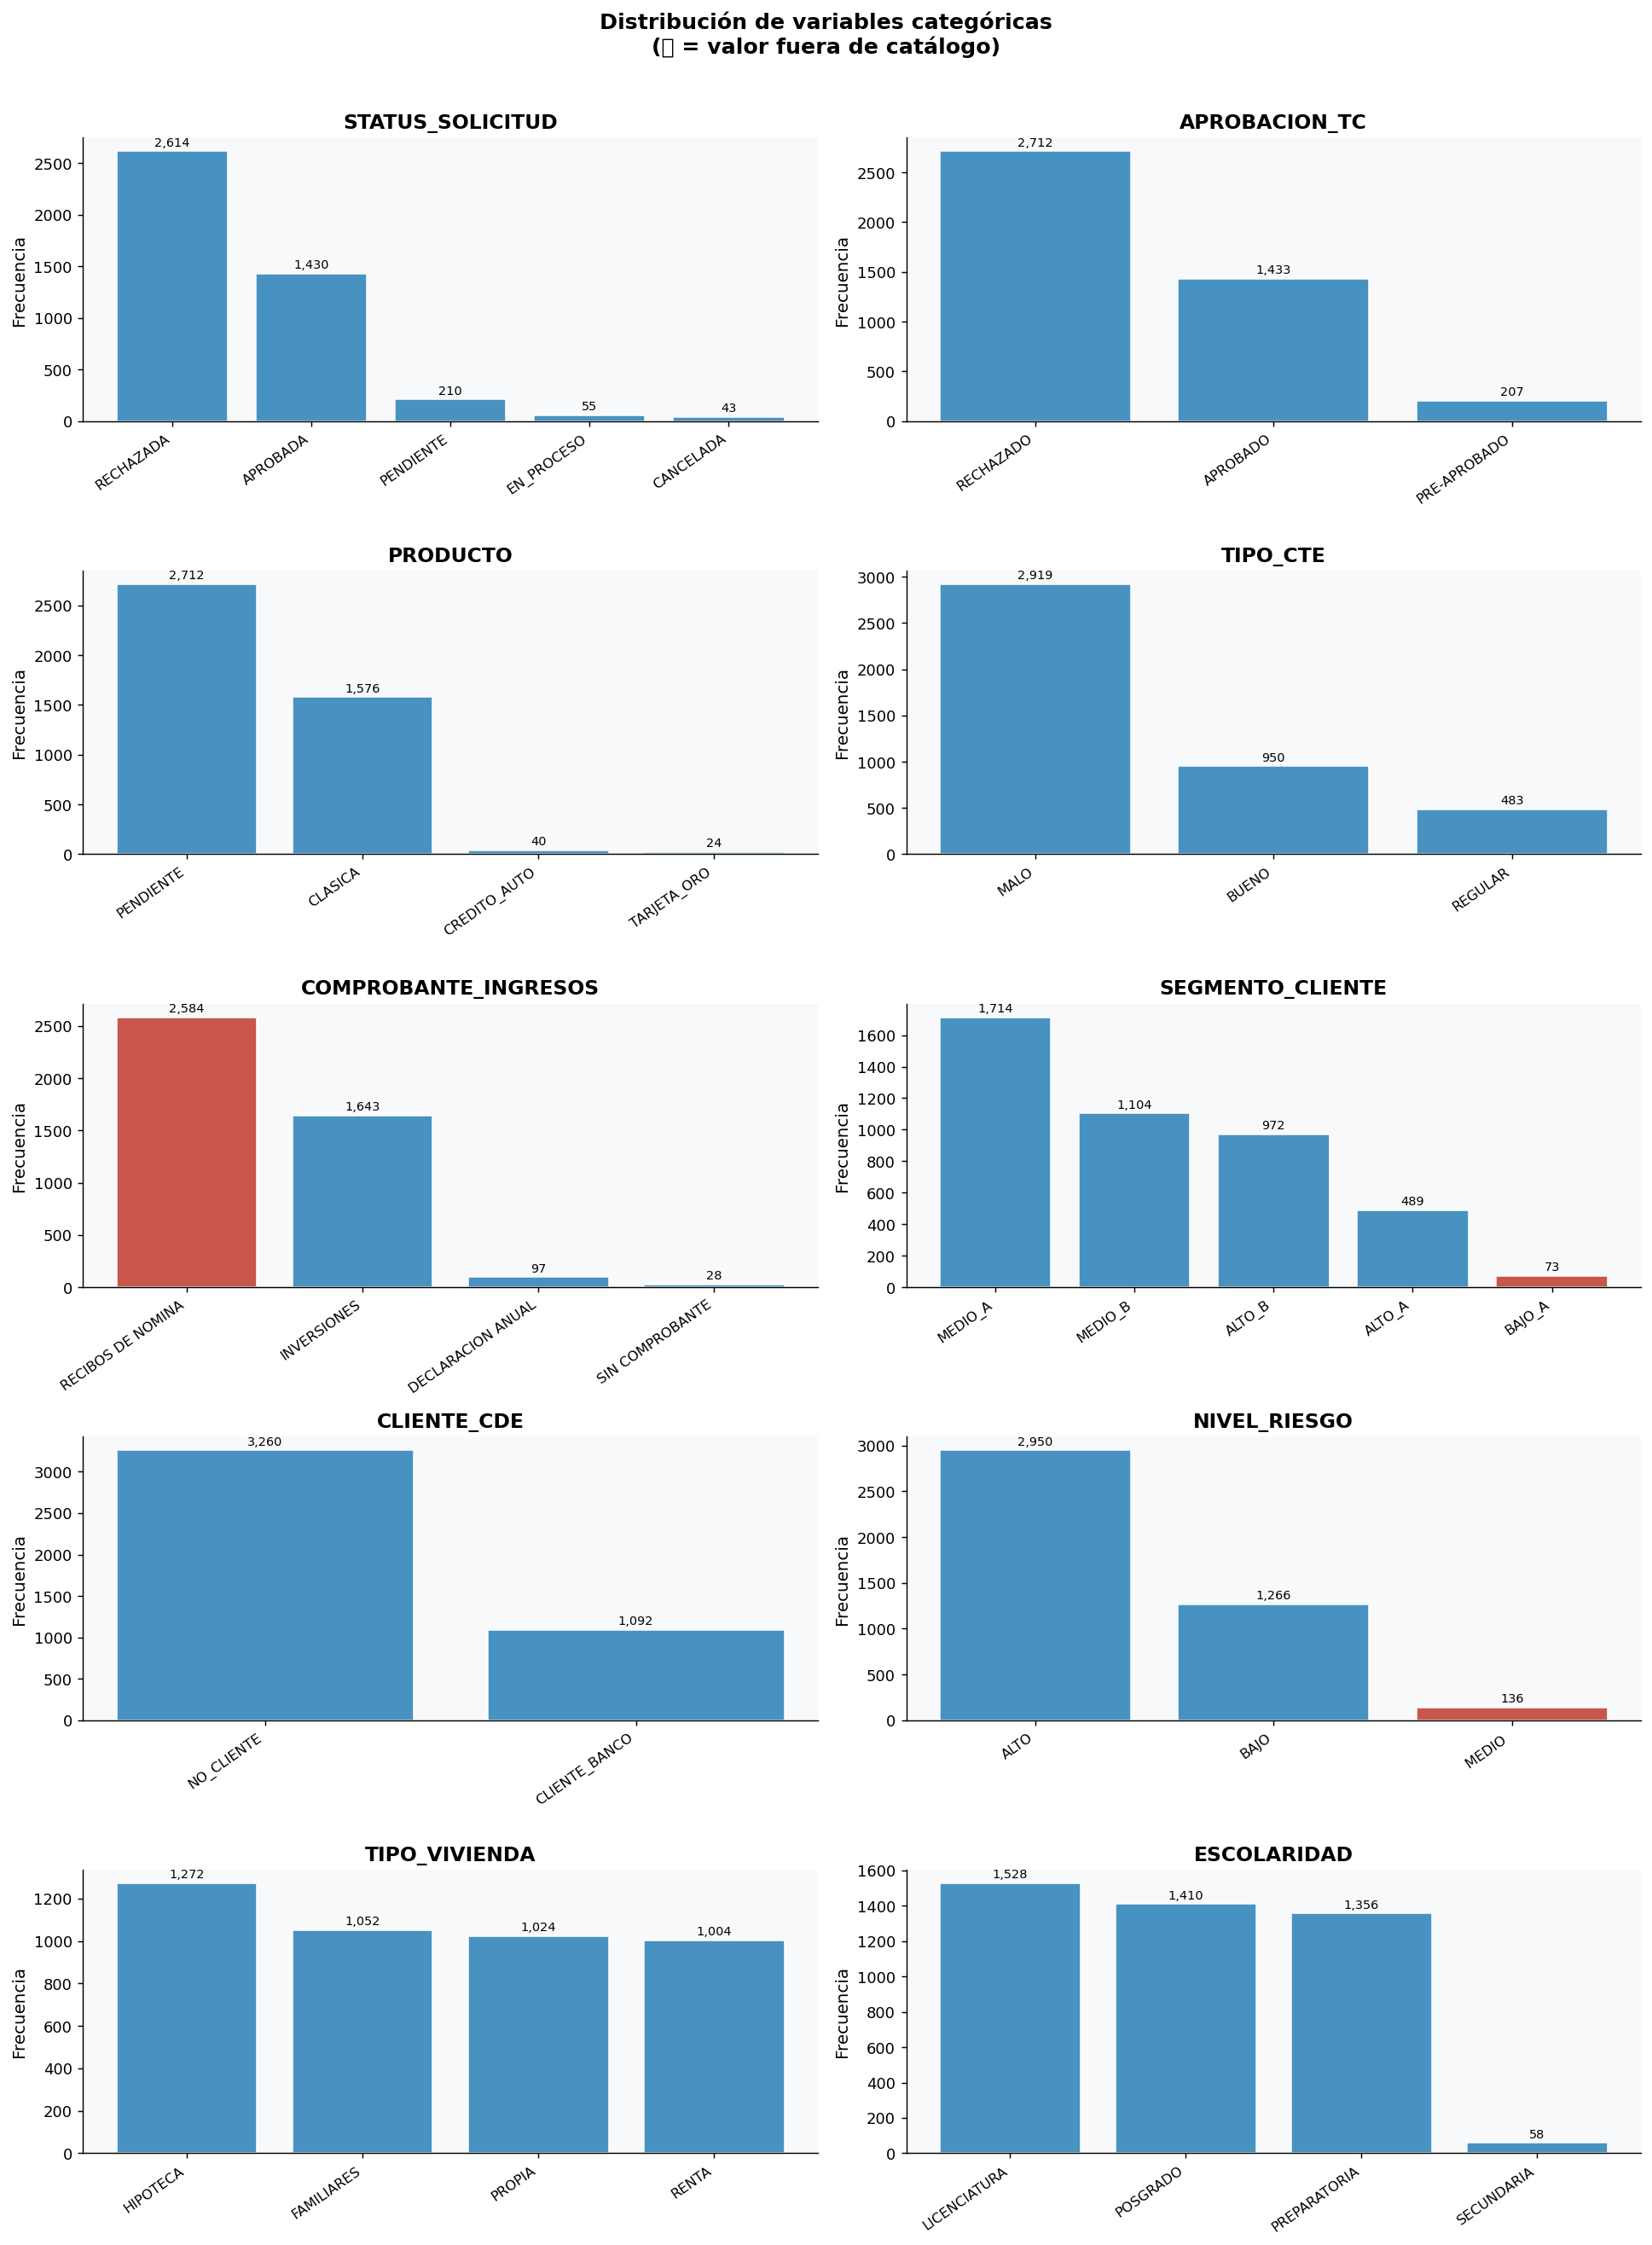

In [9]:
# ── Distribuciones de todas las categóricas ────────────────────────────────
cat_cols = list(CATALOGO.keys())

n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    if col not in df.columns:
        ax.axis("off")
        continue
    vc = df[col].value_counts(dropna=False)
    colors = [RED if (str(v) not in CATALOGO.get(col, [str(v)])) else BLUE
              for v in vc.index]
    bars = ax.bar(range(len(vc)), vc.values, color=colors, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(v) for v in vc.index], rotation=35, ha="right", fontsize=9)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Frecuencia")
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vc.max()*0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=8)

# Apagar ejes sobrantes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribución de variables categóricas\n(🔴 = valor fuera de catálogo)", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/01_categoricas.png", bbox_inches="tight")
plt.show()


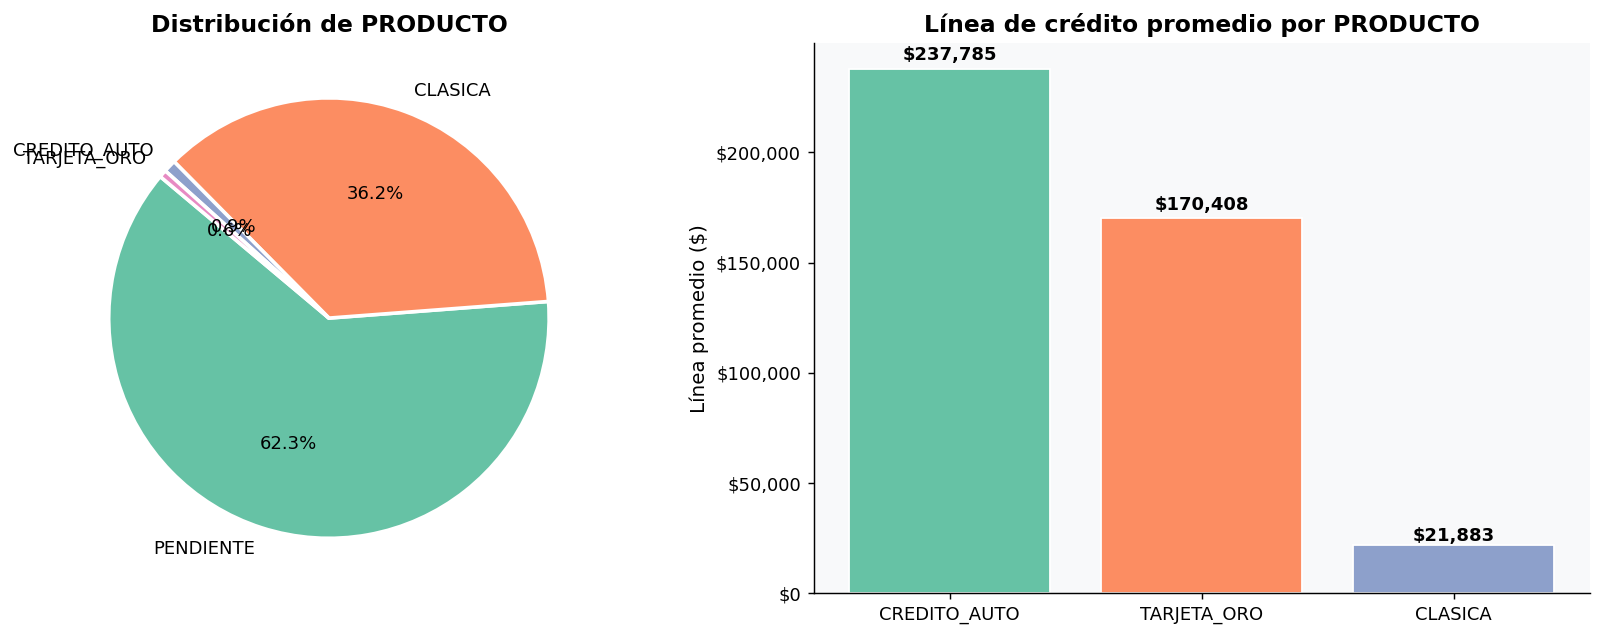


Línea de crédito promedio por producto:


,linea_promedio
PRODUCTO,
CREDITO_AUTO,"$237,785"
TARJETA_ORO,"$170,408"
CLASICA,"$21,883"


In [10]:
# ── PRODUCTO: zoom para el área de Productos de Crédito ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución general
vc = df["PRODUCTO"].value_counts(dropna=False)
wedges, texts, autotexts = axes[0].pie(
    vc.values, labels=vc.index,
    autopct="%1.1f%%", startangle=140,
    colors=sns.color_palette(PALETTE, len(vc)),
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Distribución de PRODUCTO", fontweight="bold")

# Línea de crédito promedio por producto (excluye PENDIENTE)
lc = df[df["PRODUCTO"] != "PENDIENTE"].groupby("PRODUCTO")["LINEA_CREDITO_FINAL"].mean().sort_values(ascending=False)
bars = axes[1].bar(lc.index, lc.values, color=sns.color_palette(PALETTE, len(lc)), edgecolor="white")
axes[1].set_title("Línea de crédito promedio por PRODUCTO", fontweight="bold")
axes[1].set_ylabel("Línea promedio ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, lc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/01_producto_zoom.png", bbox_inches="tight")
plt.show()

print("\nLínea de crédito promedio por producto:")
display(lc.to_frame("linea_promedio").style.format("${:,.0f}"))


---
## 5 · Variables numéricas — distribuciones y outliers

Analizamos la distribución de cada variable numérica con histograma + boxplot.  
Los boxplots revelan outliers que habrá que evaluar en la etapa de limpieza.


In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluimos IDs y cuentas
excluir = ["NUM_SOLICITUD", "CUENTA_ASIGNADA", "SUCURSAL"]
num_cols = [c for c in num_cols if c not in excluir]

print(f"Variables numéricas a analizar ({len(num_cols)}):")
print(num_cols)


Variables numéricas a analizar (11):
['LINEA_CREDITO_FINAL', 'MESES_VENCIDOS', 'INGRESO_INFERIDO', 'SUMA_LINEAS_REVOLVENTES', 'SOLICITUDES_RECHAZADAS', 'SCORE_CLIENTE', 'SCORE_COMPORTAMIENTO', 'SUMA_SALDOS_TARJETAS', 'SUMA_PAGO_MIN_TARJETAS', 'NUM_CREDITOS', 'EDAD']


In [12]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
desc = df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc["skew"] = df[num_cols].skew()
desc["CV%"]  = (df[num_cols].std() / df[num_cols].mean() * 100).round(1)
display(desc.style.format("{:,.2f}").background_gradient(subset=["skew"], cmap="RdYlGn_r"))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,CV%
LINEA_CREDITO_FINAL,"4,352.00","11,049.72","31,738.82",0.00,0.00,0.00,0.00,0.00,"7,425.00","49,999.00","150,980.00","687,000.00",6.90,287.20
MESES_VENCIDOS,"1,984.00",0.77,0.80,0.00,0.00,0.00,0.00,1.00,1.00,2.00,3.00,3.00,0.65,104.50
INGRESO_INFERIDO,"4,352.00","8,025.37","18,503.43",0.00,0.00,0.00,0.00,0.00,"10,410.00","40,329.55","79,785.77","250,000.00",4.65,230.60
SUMA_LINEAS_REVOLVENTES,"4,352.00","10,205.70","34,102.37",0.00,0.00,0.00,0.00,0.00,0.00,"59,500.00","164,591.49","680,500.00",7.59,334.20
SOLICITUDES_RECHAZADAS,"4,352.00",1.96,1.80,0.00,0.00,0.00,0.00,2.00,3.00,5.00,5.00,5.00,0.28,92.10
SCORE_CLIENTE,"4,352.00",139.23,61.45,89.00,89.00,90.00,94.00,99.00,210.00,247.00,265.49,297.00,0.81,44.10
SCORE_COMPORTAMIENTO,"4,352.00",241.86,345.91,0.00,0.00,0.00,0.00,0.00,714.00,770.00,792.00,805.00,0.74,143.00
SUMA_SALDOS_TARJETAS,"4,352.00","3,788.29","13,433.62",0.00,0.00,0.00,0.00,0.00,404.50,"21,659.50","59,793.50","210,437.00",7.28,354.60
SUMA_PAGO_MIN_TARJETAS,"4,352.00",351.98,"2,912.51",0.00,0.00,0.00,0.00,0.00,0.00,"1,134.50","6,111.90","95,758.00",19.47,827.50
NUM_CREDITOS,"4,352.00",0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,27.08,"2,429.30"


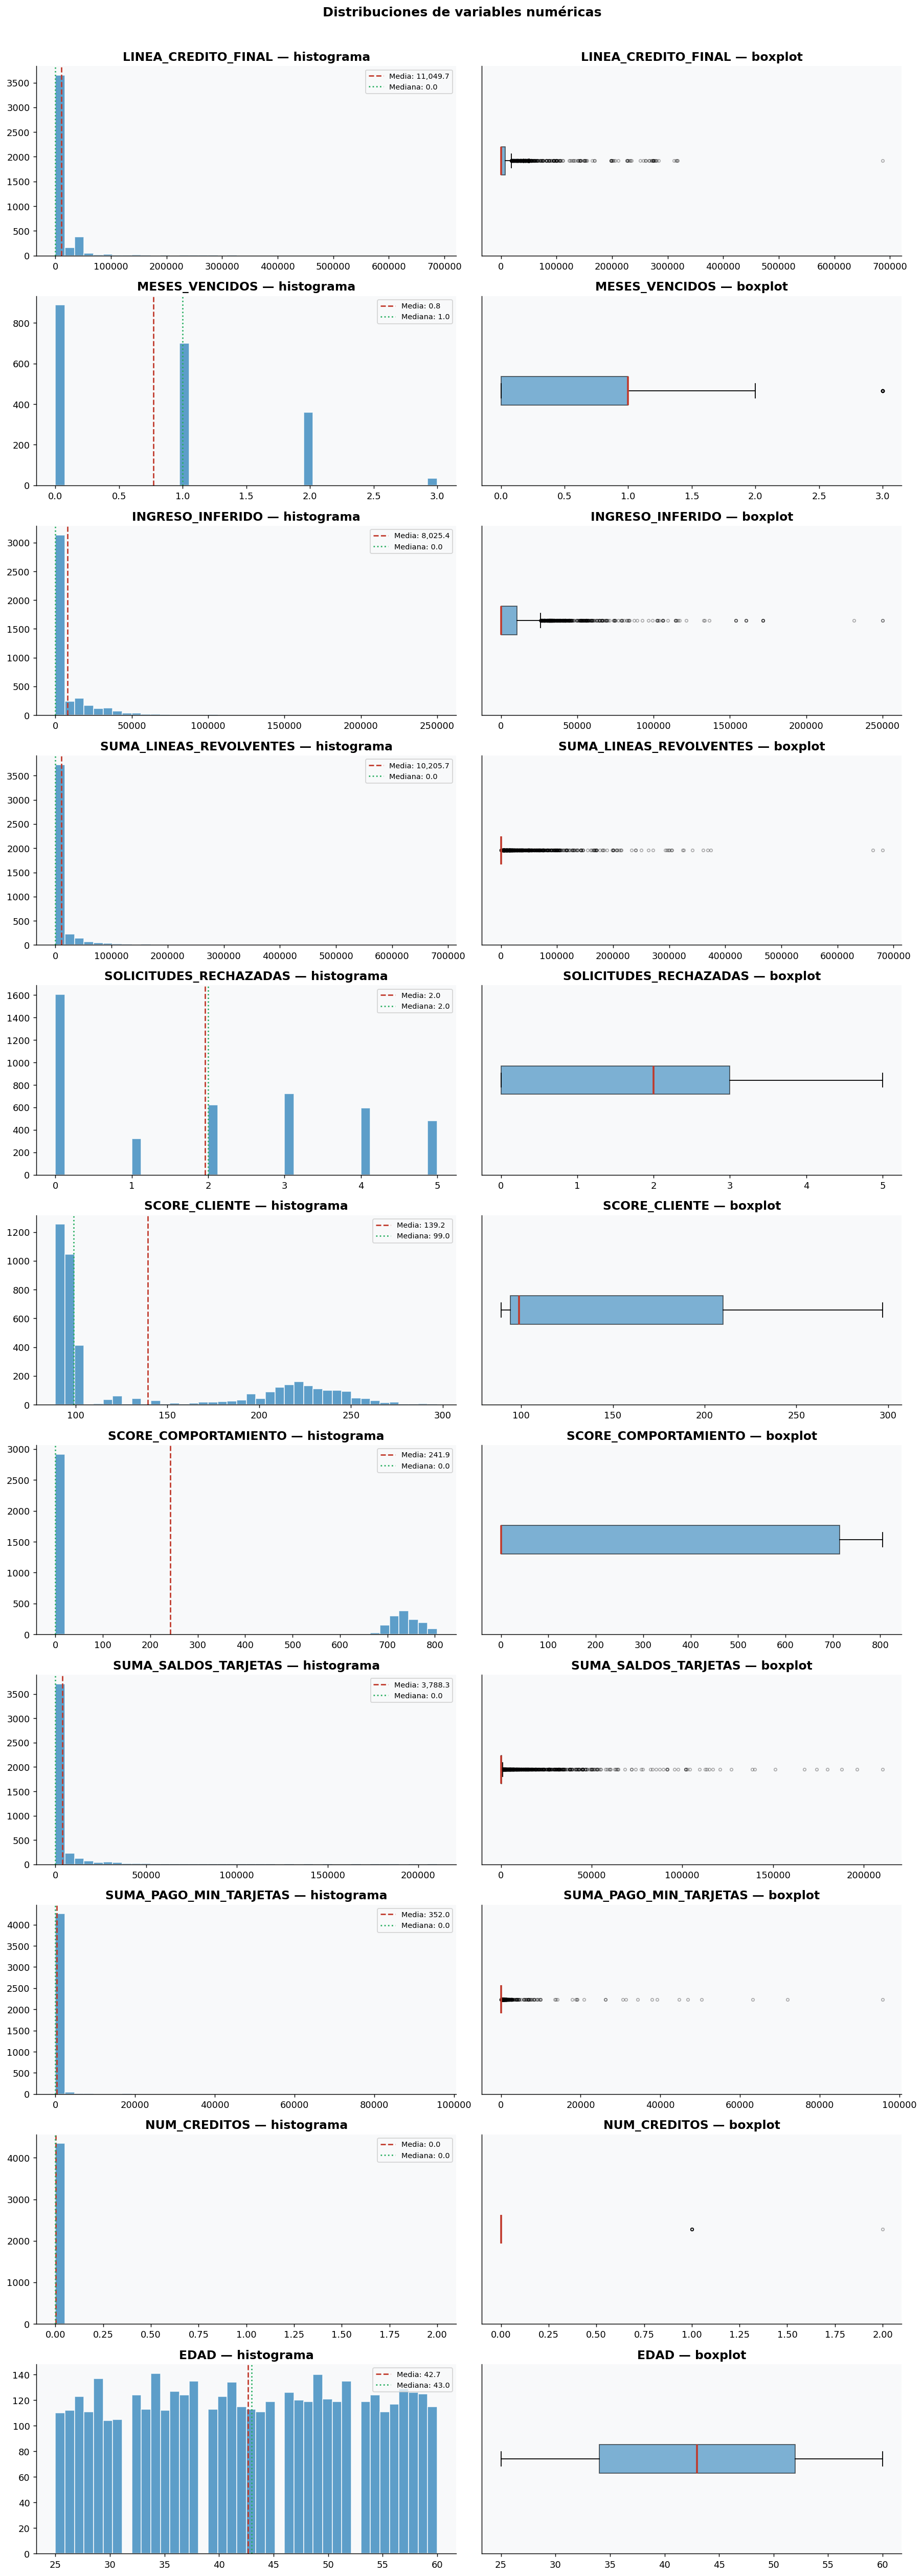

In [13]:
# ── Histograma + boxplot para cada numérica ─────────────────────────────────
n_cols_plot = 2
n_rows_plot = len(num_cols)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, n_rows_plot * 3.5))

for i, col in enumerate(num_cols):
    data = df[col].dropna()

    # Histograma
    ax_hist = axes[i][0]
    ax_hist.hist(data, bins=40, color=BLUE, alpha=0.75, edgecolor="white")
    ax_hist.axvline(data.mean(),   color=RED,   linestyle="--", linewidth=1.5, label=f"Media: {data.mean():,.1f}")
    ax_hist.axvline(data.median(), color=GREEN, linestyle=":",  linewidth=1.5, label=f"Mediana: {data.median():,.1f}")
    ax_hist.set_title(f"{col} — histograma", fontweight="bold")
    ax_hist.legend(fontsize=8)

    # Boxplot
    ax_box = axes[i][1]
    bp = ax_box.boxplot(data, vert=False, patch_artist=True,
                        boxprops=dict(facecolor=BLUE, alpha=0.6),
                        medianprops=dict(color=RED, linewidth=2),
                        flierprops=dict(marker="o", color=RED, alpha=0.3, markersize=3))
    ax_box.set_title(f"{col} — boxplot", fontweight="bold")
    ax_box.set_yticks([])

plt.suptitle("Distribuciones de variables numéricas", fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig("../reports/figures/01_numericas.png", bbox_inches="tight")
plt.show()


In [14]:
# ── Detección de outliers (método IQR) ──────────────────────────────────────
print("══ OUTLIERS POR VARIABLE (método IQR) ══\n")
outlier_report = {}
for col in num_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    pct_out = n_out / len(data) * 100
    outlier_report[col] = {
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "límite_inf": lower, "límite_sup": upper,
        "n_outliers": n_out, "pct_outliers": round(pct_out, 2)
    }
    estado = "" if pct_out > 5 else ("X" if pct_out > 15 else "✓")
    print(f"  {estado} {col}: {n_out:,} outliers ({pct_out:.1f}%) | rango válido IQR: [{lower:,.1f}, {upper:,.1f}]")

outlier_df = pd.DataFrame(outlier_report).T


══ OUTLIERS POR VARIABLE (método IQR) ══

   LINEA_CREDITO_FINAL: 691 outliers (15.9%) | rango válido IQR: [-11,137.5, 18,562.5]
  ✓ MESES_VENCIDOS: 35 outliers (1.8%) | rango válido IQR: [-1.5, 2.5]
   INGRESO_INFERIDO: 483 outliers (11.1%) | rango válido IQR: [-15,615.0, 26,025.0]
   SUMA_LINEAS_REVOLVENTES: 1,034 outliers (23.8%) | rango válido IQR: [0.0, 0.0]
  ✓ SOLICITUDES_RECHAZADAS: 0 outliers (0.0%) | rango válido IQR: [-4.5, 7.5]
  ✓ SCORE_CLIENTE: 0 outliers (0.0%) | rango válido IQR: [-80.0, 384.0]
  ✓ SCORE_COMPORTAMIENTO: 0 outliers (0.0%) | rango válido IQR: [-1,071.0, 1,785.0]
   SUMA_SALDOS_TARJETAS: 1,008 outliers (23.2%) | rango válido IQR: [-606.8, 1,011.2]
   SUMA_PAGO_MIN_TARJETAS: 771 outliers (17.7%) | rango válido IQR: [0.0, 0.0]
  ✓ NUM_CREDITOS: 8 outliers (0.2%) | rango válido IQR: [0.0, 0.0]
  ✓ EDAD: 0 outliers (0.0%) | rango válido IQR: [7.0, 79.0]


---
## 6 · Validaciones adicionales contra el catálogo

Validamos restricciones específicas mencionadas en el excel:
- `SUCURSAL` debe estar entre 100 y 299
- `NUM_CREDITOS` solo puede ser 0, 1 o 2
- `MESES_VENCIDOS` solo puede ser 0, 1, 2, 3 o NULL
- `CUENTA_ASIGNADA` solo debería existir si la solicitud fue aprobada


In [15]:
print("══ VALIDACIONES ESPECÍFICAS DEL CATÁLOGO ══\n")

# SUCURSAL rango 100-299
inv_suc = df[(df["SUCURSAL"] < 100) | (df["SUCURSAL"] > 299)]
print(f"  SUCURSAL fuera de rango [100-299]: {len(inv_suc):,} registros")
if len(inv_suc) > 0:
    print(f"    Valores encontrados: {sorted(df['SUCURSAL'].unique())}")

# NUM_CREDITOS solo 0, 1, 2
inv_cred = df[~df["NUM_CREDITOS"].isin([0, 1, 2])]
print(f"\n  NUM_CREDITOS fuera de [0,1,2]: {len(inv_cred):,} registros")
if len(inv_cred) > 0:
    print(f"    Valores: {df['NUM_CREDITOS'].unique()}")

# MESES_VENCIDOS solo 0, 1, 2, 3 o null
inv_mv = df[df["MESES_VENCIDOS"].notna() & ~df["MESES_VENCIDOS"].isin([0, 1, 2, 3])]
print(f"\n  MESES_VENCIDOS con valores inválidos (no nulo y no en 0-3): {len(inv_mv):,} registros")
print(f"    Nulos en MESES_VENCIDOS: {df['MESES_VENCIDOS'].isnull().sum():,} ({df['MESES_VENCIDOS'].isnull().mean()*100:.1f}%)")

# CUENTA_ASIGNADA vs STATUS_SOLICITUD
cuenta_sin_aprobar = df[(df["CUENTA_ASIGNADA"].notna()) & (~df["STATUS_SOLICITUD"].isin(["APROBADA"]))]
sin_cuenta_aprobada = df[(df["STATUS_SOLICITUD"] == "APROBADA") & (df["CUENTA_ASIGNADA"].isna())]
print(f"\n  CUENTA_ASIGNADA asignada sin STATUS=APROBADA: {len(cuenta_sin_aprobar):,}")
print(f"  STATUS=APROBADA pero sin CUENTA_ASIGNADA:     {len(sin_cuenta_aprobada):,}")


══ VALIDACIONES ESPECÍFICAS DEL CATÁLOGO ══

  SUCURSAL fuera de rango [100-299]: 0 registros

  NUM_CREDITOS fuera de [0,1,2]: 0 registros

  MESES_VENCIDOS con valores inválidos (no nulo y no en 0-3): 0 registros
    Nulos en MESES_VENCIDOS: 2,368 (54.4%)

  CUENTA_ASIGNADA asignada sin STATUS=APROBADA: 3
  STATUS=APROBADA pero sin CUENTA_ASIGNADA:     0


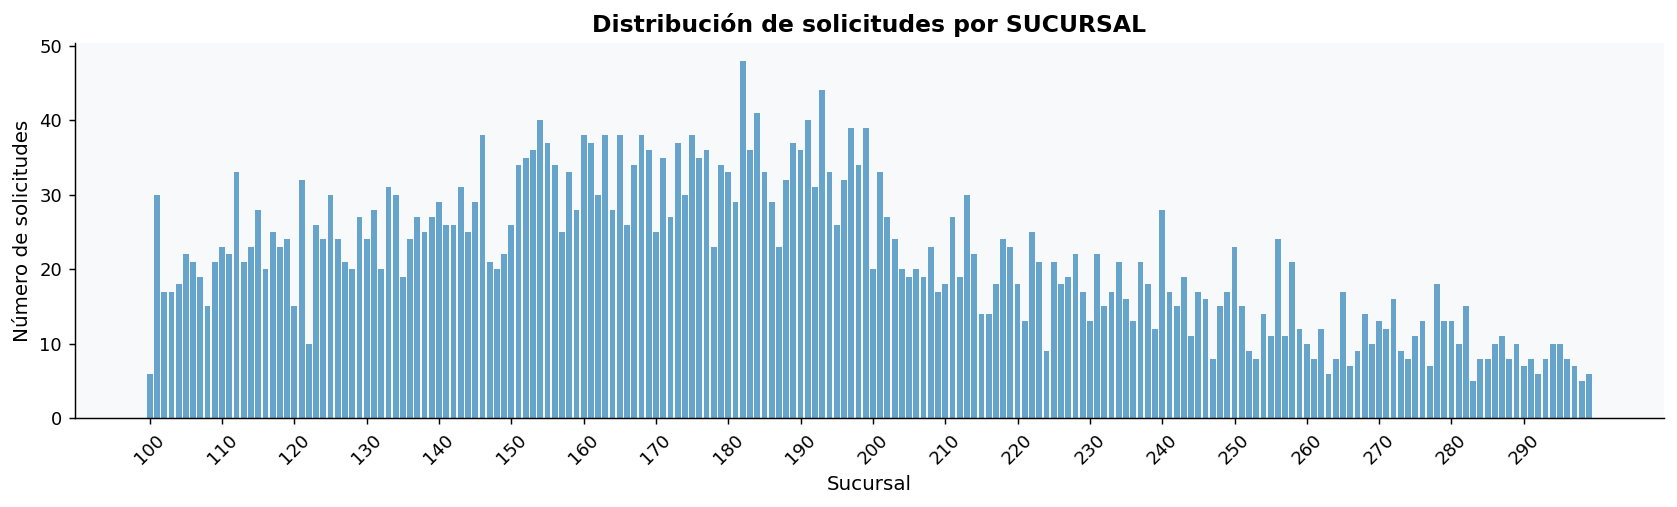


Total de sucursales distintas: 200


In [16]:
# ── Distribución de SUCURSAL ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
suc_counts = df["SUCURSAL"].value_counts().sort_index()
ax.bar(suc_counts.index.astype(str), suc_counts.values, color=BLUE, alpha=0.7, width=0.8)
ax.set_title("Distribución de solicitudes por SUCURSAL", fontweight="bold")
ax.set_xlabel("Sucursal")
ax.set_ylabel("Número de solicitudes")
ax.set_xticks(range(0, len(suc_counts), max(1, len(suc_counts)//20)))
ax.set_xticklabels(list(suc_counts.index)[::max(1, len(suc_counts)//20)], rotation=45)
plt.tight_layout()
plt.savefig("../reports/figures/01_sucursales.png", bbox_inches="tight")
plt.show()
print(f"\nTotal de sucursales distintas: {df['SUCURSAL'].nunique()}")


---
## 7 · Correlaciones entre variables numéricas

Una correlación alta puede indicar redundancia (feature engineering posterior).  
Correlaciones con `LINEA_CREDITO_FINAL` son especialmente relevantes para el área.


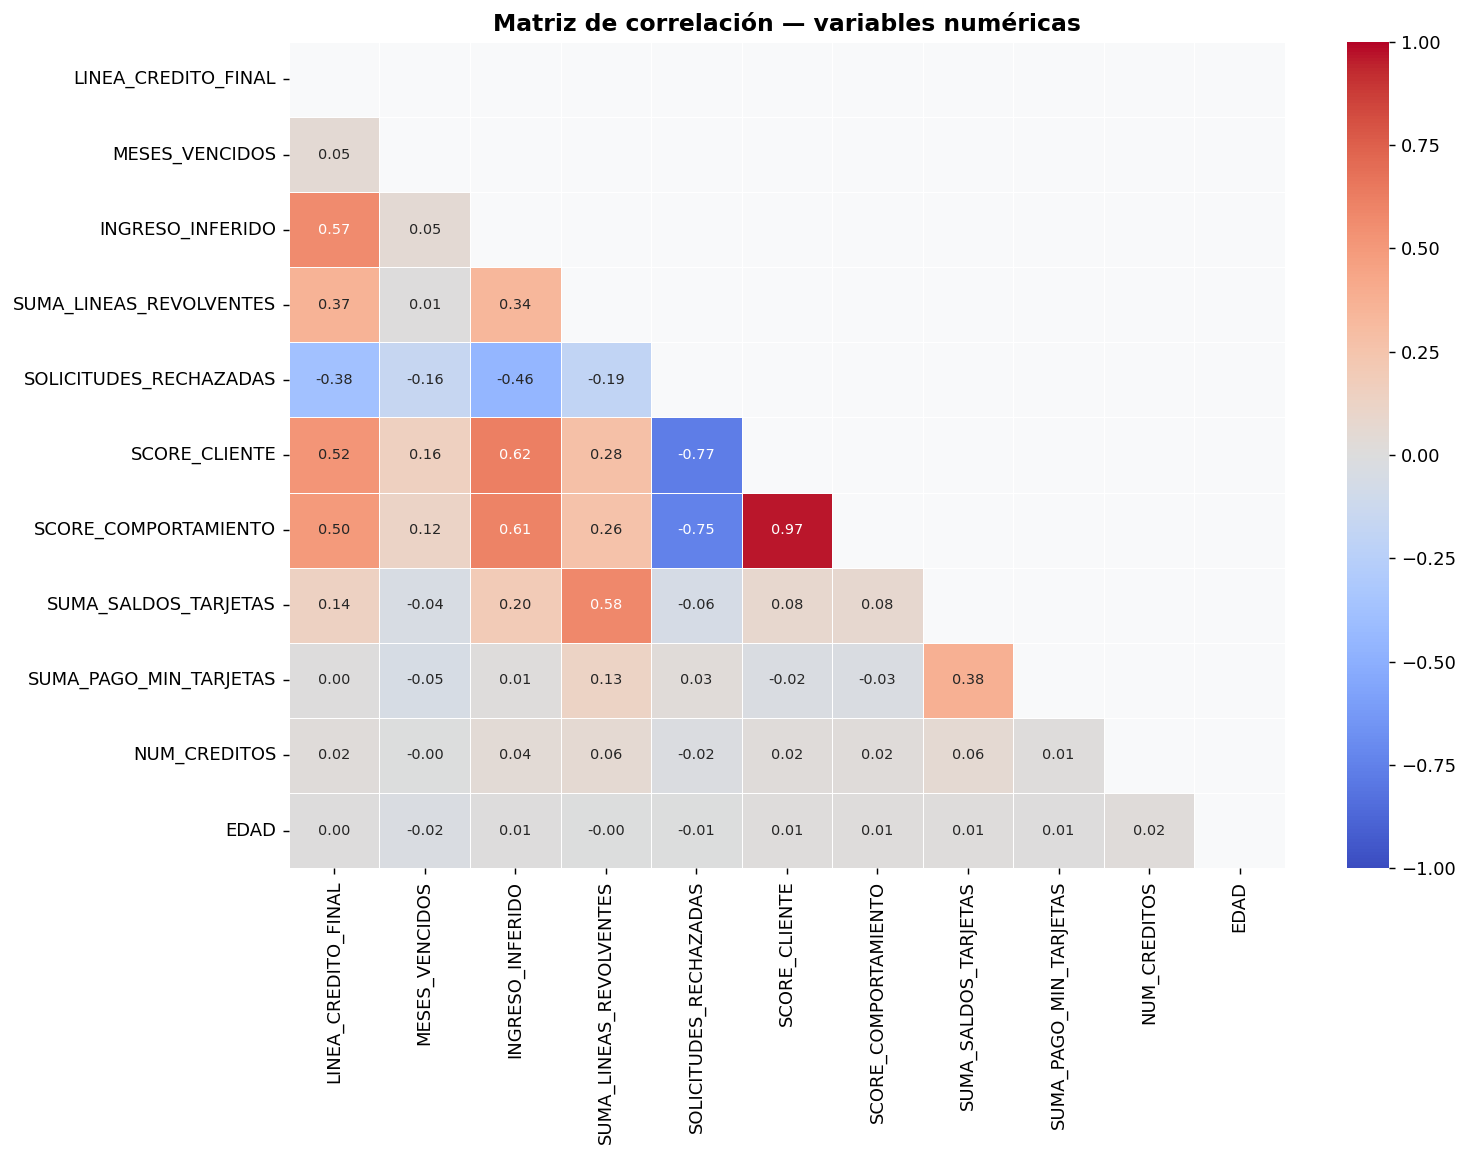

In [17]:
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Matriz de correlación — variables numéricas", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/01_correlaciones.png", bbox_inches="tight")
plt.show()


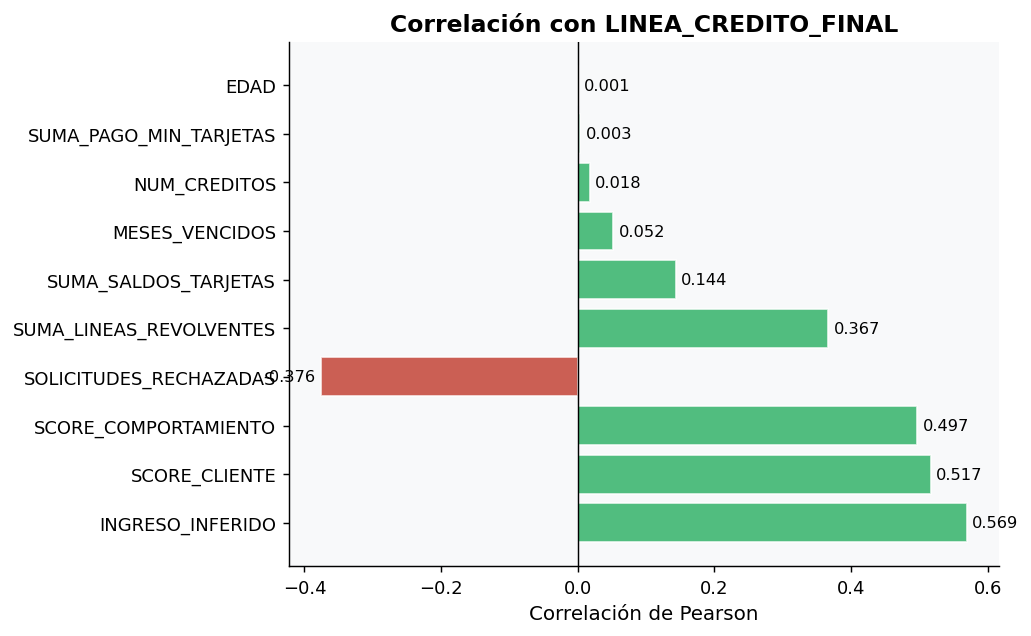


Ranking de correlaciones con LINEA_CREDITO_FINAL:


,correlacion
INGRESO_INFERIDO,0.5693
SCORE_CLIENTE,0.5168
SCORE_COMPORTAMIENTO,0.4968
SOLICITUDES_RECHAZADAS,-0.3756
SUMA_LINEAS_REVOLVENTES,0.3669
SUMA_SALDOS_TARJETAS,0.1436
MESES_VENCIDOS,0.0517
NUM_CREDITOS,0.0178
SUMA_PAGO_MIN_TARJETAS,0.0034
EDAD,0.0013


In [19]:
# ── Top correlaciones con LINEA_CREDITO_FINAL ────────────────────────────────
if "LINEA_CREDITO_FINAL" in corr_matrix.columns:
    corr_target = corr_matrix["LINEA_CREDITO_FINAL"].drop("LINEA_CREDITO_FINAL").sort_values(key=abs, ascending=False)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = [RED if v < 0 else GREEN for v in corr_target.values]
    bars = ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Correlación con LINEA_CREDITO_FINAL", fontweight="bold")
    ax.set_xlabel("Correlación de Pearson")
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in corr_target.values], padding=3, fontsize=9)
    plt.tight_layout()
    plt.savefig("../reports/figures/01_corr_target.png", bbox_inches="tight")
    plt.show()
    
    print("\nRanking de correlaciones con LINEA_CREDITO_FINAL:")
    display(corr_target.to_frame("correlacion").style.format("{:.4f}").background_gradient(cmap="RdYlGn", vmin=-1, vmax=1))


---
## 8 · Resumen de hallazgos y decisiones pendientes

Esta sección se completa **después de revisar los outputs** de las secciones anteriores.


In [20]:
print("══════════════════════════════════════════════════════")
print("  RESUMEN GENERAL DEL DATASET")
print("══════════════════════════════════════════════════════")
print(f"  Total registros:        {len(df):,}")
print(f"  Total columnas:         {df.shape[1]}")
print(f"  Columnas con nulos:     {(df.isnull().sum() > 0).sum()}")
print(f"  Duplicados exactos:     {df.duplicated().sum():,}")
print()
print("  DISTRIBUCIÓN DE STATUS_SOLICITUD:")
for v, c in df["STATUS_SOLICITUD"].value_counts().items():
    pct = c / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"    {v:<20} {c:>5,}  ({pct:>5.1f}%)  {bar}")
print()
print("  DISTRIBUCIÓN DE PRODUCTO:")
for v, c in df["PRODUCTO"].value_counts(dropna=False).items():
    pct = c / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"    {str(v):<20} {c:>5,}  ({pct:>5.1f}%)  {bar}")


══════════════════════════════════════════════════════
  RESUMEN GENERAL DEL DATASET
══════════════════════════════════════════════════════
  Total registros:        4,352
  Total columnas:         27
  Columnas con nulos:     4
  Duplicados exactos:     0

  DISTRIBUCIÓN DE STATUS_SOLICITUD:
    RECHAZADA            2,614  ( 60.1%)  ██████████████████████████████
    APROBADA             1,430  ( 32.9%)  ████████████████
    PENDIENTE              210  (  4.8%)  ██
    EN_PROCESO              55  (  1.3%)  
    CANCELADA               43  (  1.0%)  

  DISTRIBUCIÓN DE PRODUCTO:
    PENDIENTE            2,712  ( 62.3%)  ███████████████████████████████
    CLASICA              1,576  ( 36.2%)  ██████████████████
    CREDITO_AUTO            40  (  0.9%)  
    TARJETA_ORO             24  (  0.6%)  


---
## Decisiones pendientes

> **Completa esta sección después de revisar los outputs y compartirlos.**

| # | Variable / Problema | Hallazgo | Decisión propuesta |
|---|---|---|---|
| 1 | `MESES_VENCIDOS` nulos | % de nulos encontrados | Imputar / eliminar / dejar como categoría separada |
| 2 | `PRODUCTO = PENDIENTE` | % de registros sin producto | Excluir del análisis de productos / modelar aparte |
| 3 | `CUENTA_ASIGNADA` | Inconsistencias con STATUS | Validar regla de negocio |
| 4 | Outliers en `LINEA_CREDITO_FINAL` | % de outliers | Cap / winsorización / eliminar |
| 5 | Outliers en `INGRESO_INFERIDO` | % de outliers | Por definir |
| 6 | Variables correlacionadas | Pares con r > 0.8 | Evaluar eliminar en feature engineering |

---
*Próximo paso → `02_data_cleaning.ipynb`*
